<a href="https://colab.research.google.com/github/vishnuiyer23ug-stack/computational-statistics-course-4/blob/main/Class_06_polynomial_regression_bias_variance_tradeoff.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Polynomial regression
Let's try loading a dataset a dataset from Kaggle. To do this, you will need to [create a legacy API key from Kaggle](https://www.kaggle.com/settings). This will download a kaggle.json file.

In [1]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"vishnuiy","key":"486d6432bba091fa3d92dbda2f2ebdd4"}'}

In [2]:
# Change the permissions of the kaggle.json file such that only you can read/write the file.
# This is to prevent someone else from modifying the file.
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [3]:
!pip install -q kaggle # Install that Kaggle package to interact with Kaggle's datasets; pip is python's package manager

In [4]:
!kaggle datasets download -d mirajdeepbhandari/polynomial-regression

Dataset URL: https://www.kaggle.com/datasets/mirajdeepbhandari/polynomial-regression
License(s): CC0-1.0
  0% 0.00/1.18k [00:00<?, ?B/s]
100% 1.18k/1.18k [00:00<00:00, 3.77MB/s]


In [5]:
!unzip polynomial-regression.zip

Archive:  polynomial-regression.zip
  inflating: Ice_cream selling data.csv  


In [6]:
# Import necessary packages
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,r2_score
from sklearn.preprocessing import scale, PolynomialFeatures
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error, r2_score
from sklearn.metrics import PredictionErrorDisplay

In [7]:
os.listdir() # Look for the files/directories within the current directory

['.config',
 'Ice_cream selling data.csv',
 'kaggle.json',
 'polynomial-regression.zip',
 'sample_data']

The Ice_cream selling data.csv is available!

In [8]:
data = pd.read_csv("Ice_cream selling data.csv") # Read the csv file into a pandas dataframe
type(data)

pandas.core.frame.DataFrame

In [10]:
data.head()

,Temperature (°C),Ice Cream Sales (units)
0,-4.662263,41.842986
1,-4.316559,34.661120
2,-4.213985,39.383001
3,-3.949661,37.539845
4,-3.578554,32.284531


In [11]:
data.shape

(49, 2)

In [12]:
data.info() # Gives basic information about the dataframe

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49 entries, 0 to 48
Data columns (total 2 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Temperature (°C)         49 non-null     float64
 1   Ice Cream Sales (units)  49 non-null     float64
dtypes: float64(2)
memory usage: 916.0 bytes


In [13]:
data.describe() # Gives basic statistics about the columns of the dataframe

,Temperature (°C),Ice Cream Sales (units)
count,49.000000,49.000000
mean,0.271755,15.905308
std,2.697672,12.264682
min,-4.662263,0.328626
25%,-2.111870,4.857988
50%,0.688781,12.615181
75%,2.784836,25.142082
max,4.899032,41.842986


In [15]:
X = data.iloc[:, :-1] # We are extracting the features and response. The first : tells python to take all the rows, and we take it up until the last column (i.e., :-1)
y = data.iloc[:, -1] # This tells python to take only the last column.

In [16]:
# Fitting the data to a linear model

In [17]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [18]:
model = LinearRegression()
model.fit(X_train,y_train)

LinearRegression()

In [52]:
model.score(X_train, y_train) # Training R^2. It's really poor

0.06579063815950037

In [25]:
predict = model.predict(X_test)

In [28]:
r2_score(y_test,predict) # This means that our model does a worse job at predicting the response variable than the mean.


-0.5751270190188227

In [22]:
model.coef_, model.intercept_

(array([-1.14658686]), np.float64(17.139213127718417))

In [29]:
x_vals = np.arange(-5,5)

In [30]:
y_vals = model.coef_*x_vals + model.intercept_

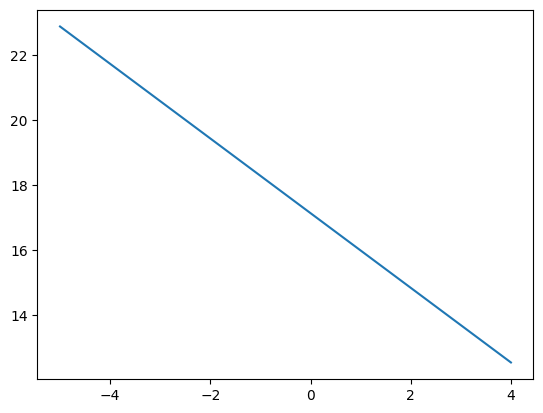

In [32]:
plt.plot(x_vals,y_vals)

In [40]:
y_mean = np.mean(y)
y_mean = np.array([y_mean for i in range(10)])

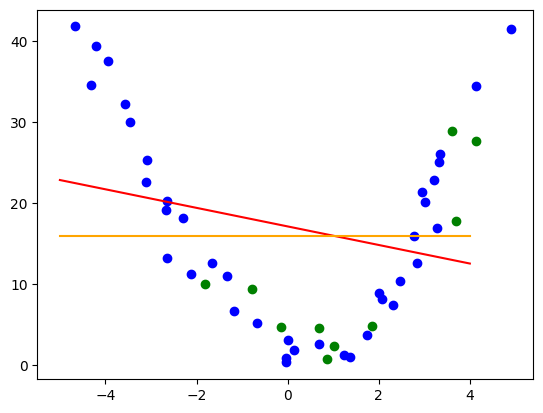

In [44]:
plt.scatter(X_test,y_test,color="green") # For the training data, the mean is a better estimate than the regression line
plt.scatter(X_train,y_train,color="blue") # For the testing data, the regression model is a marginally better estimate than the mean.
plt.plot(x_vals,y_vals, color="red") # The regression model
plt.plot(x_vals,y_mean,color="orange") # The mean of the data


In [ ]:
# Since the linear model was so bad, we now switch to a polynomial model. This is still linear in parameters, but
# it is polynomial in X (i.e., the features)

In [78]:
poly_features = PolynomialFeatures(degree=6) # degree determines the degree of the features (self-explanatory)
X_transformed = poly_features.fit_transform(X)
X_transformed # This is the features vector. The first column is 1 as usual. The second column is X1 which is the same as before.
# The third column gives us the square of X1 (and thus X1^2) giving us the polynomial in X form. The e+01 means *10^1.

array([[ 1.00000000e+00, -4.66226268e+00,  2.17366933e+01,
        -1.01342174e+02,  4.72483834e+02, -2.20284375e+03,
         1.02702362e+04],
       [ 1.00000000e+00, -4.31655945e+00,  1.86326855e+01,
        -8.04290944e+01,  3.47176967e+02, -1.49861002e+03,
         6.46883923e+03],
       [ 1.00000000e+00, -4.21398476e+00,  1.77576676e+01,
        -7.48305407e+01,  3.15334758e+02, -1.32881587e+03,
         5.59960982e+03],
       [ 1.00000000e+00, -3.94966109e+00,  1.55998227e+01,
        -6.16140128e+01,  2.43354469e+02, -9.61167676e+02,
         3.79628657e+03],
       [ 1.00000000e+00, -3.57855372e+00,  1.28060467e+01,
        -4.58271260e+01,  1.63994832e+02, -5.86864316e+02,
         2.10012548e+03],
       [ 1.00000000e+00, -3.45571170e+00,  1.19419433e+01,
        -4.12679133e+01,  1.42610011e+02, -4.92819082e+02,
         1.70304067e+03],
       [ 1.00000000e+00, -3.10844012e+00,  9.66239999e+00,
        -3.00349918e+01,  9.33619735e+01, -2.90210104e+02,
         9.0210073

In [79]:
# Now we run the same code for running the regression but on X_transformed

In [84]:
X_train, X_test, y_train, y_test = train_test_split(X_transformed, y, test_size = 0.2, random_state = 42)
model = LinearRegression()
model.fit(X_train,y_train)
train_r2 = model.score(X_train, y_train) # Training R^2 is now super high

In [85]:
# Predicted values for the train data
train_predict = model.predict(X_train)

In [88]:
# Predcted values for the test data
test_predict = model.predict(X_test)
test_r2 = model.score(X_test,y_test) # Test R^2 is also pretty high

In [89]:
train_error = mean_squared_error(y_train, train_predict)
print(train_error)
test_error = mean_squared_error(y_test, test_predict)
print(test_error)
print(train_r2)
print(test_r2)

# We do this exercise to see how the MSE changes as we change the degree of X in the model. As we increase the degrees, the model becomes
# more and more specific to the training data, thus leading to overfitting. Every time we increase the degree, the MSE of the train data
# reduces and that of the test data increases. As we increase the degree, the train R2 increases and the test R2 falls.

5.090584162858846
25.464475546867938
0.9668204963106728
0.7313950333963133


In [119]:
n = 10
train_r2 = np.zeros(n)
test_r2 = np.zeros(n)
train_error = np.zeros(n)
test_error = np.zeros(n)


for i in range(n):
  poly_features = PolynomialFeatures(degree=i) # degree determines the degree of the features (self-explanatory)
  X_transformed = poly_features.fit_transform(X)
  X_train, X_test, y_train, y_test = train_test_split(X_transformed, y, test_size = 0.3, random_state = 42)
  model = LinearRegression()
  model.fit(X_train,y_train)
  train_r2[i] = model.score(X_train, y_train)
  train_predict = model.predict(X_train)
  test_predict = model.predict(X_test)
  test_r2[i] = model.score(X_test,y_test)
  train_error[i] = mean_squared_error(y_train, train_predict)
  test_error[i] = mean_squared_error(y_test, test_predict)


(0.0, 100.0)

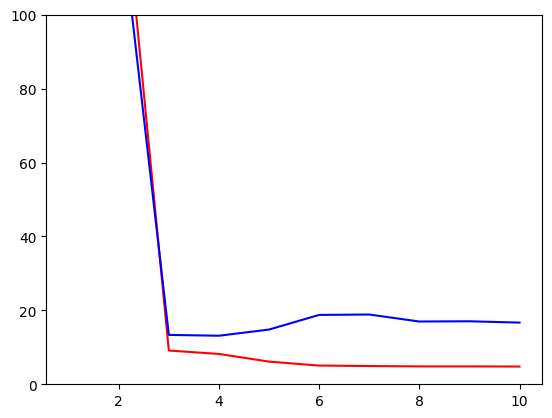

In [120]:
i = np.arange(1,n+1,1)
plt.plot(i,train_error,color="red")
plt.plot(i,test_error,color="blue")
plt.ylim((0,100))

In [121]:
train_r2

array([0.        , 0.02664525, 0.94014573, 0.9462588 , 0.95982347,
       0.96683564, 0.96765889, 0.96831783, 0.96831924, 0.96857994])

(0.0, 1.0)

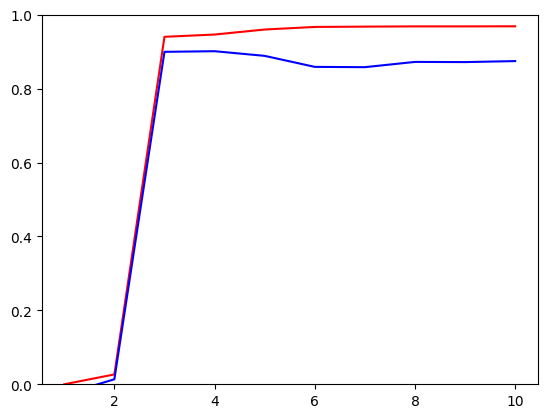

In [122]:
i = np.arange(1,n+1,1)
plt.plot(i,train_r2,color="red")
plt.plot(i,test_r2,color="blue")
plt.ylim((0,1))